# Support Resistance

In [12]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)




from utils.support_resistance import detect_support_resistance, plot_support_resistance


def support_resistance_analysis(lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size*(lot + 1)
    end_date_ind = n - lot_size*lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    print(start_date, end_date)

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    support, resistance, _df = detect_support_resistance(_df)
    _support, _resistance = [], []
    for price, strength in support:
        _support.append((price, strength, 0))
    for price, strength in resistance:
        _resistance.append((price, strength, 0))
    fig = plot_support_resistance(_df, _support, _resistance)
    return support, resistance, _df

2025-02-10 00:00:00 2025-09-18 00:00:00


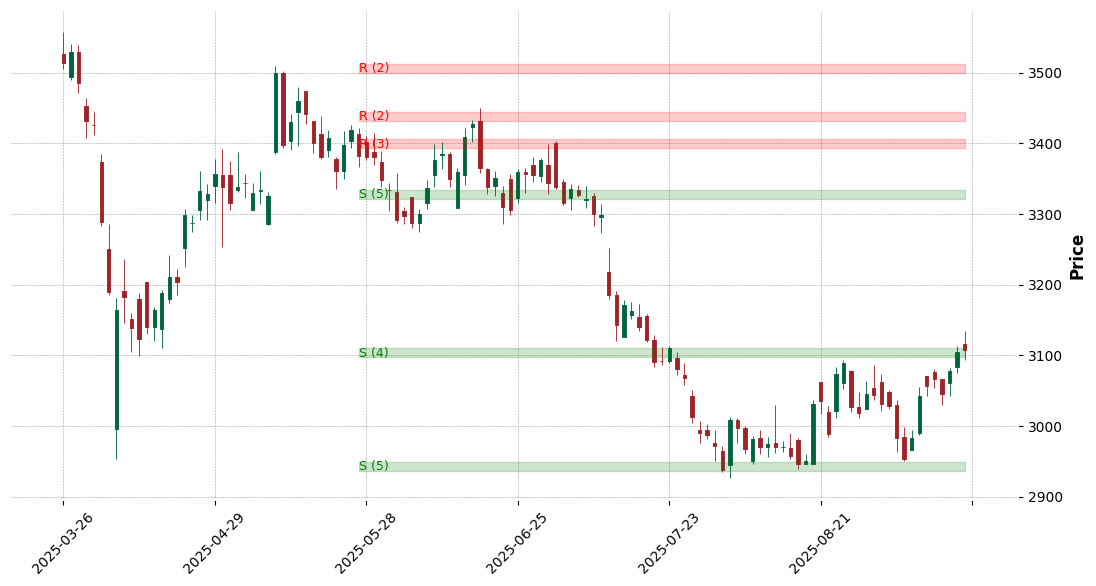

In [13]:
lot = 1
lot_size = 150
support, resistance, _df = support_resistance_analysis(lot, lot_size)

### Claude Function

In [1]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)




from utils.support_resistance import detect_support_resistance_claude, plot_support_resistance


def support_resistance_analysis_claude(lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size*(lot + 1)
    end_date_ind = n - lot_size*lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    print(start_date, end_date)

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    support, resistance, _df = detect_support_resistance_claude(_df)
    # fig = plot_support_resistance(_df, support, resistance)
    return _df, support, resistance

In [2]:
lot = 1
lot_size = 150
_df, support, resistance = support_resistance_analysis_claude(lot, lot_size)

2025-02-10 00:00:00 2025-09-18 00:00:00


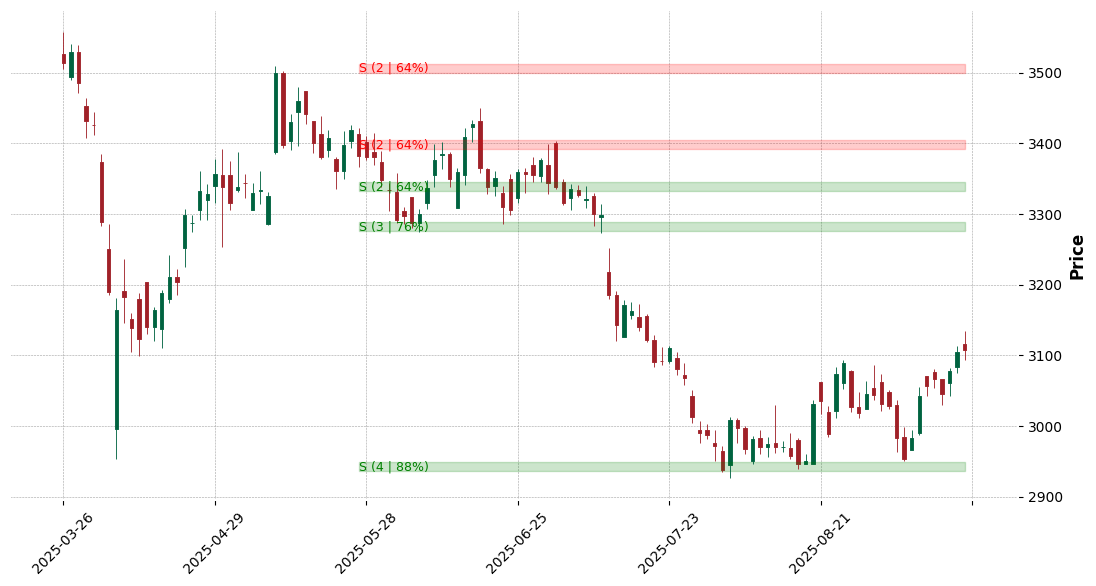

In [3]:
fig = plot_support_resistance(_df, support, resistance)

In [4]:
support

[(np.float64(2942.7981137983197), 4, np.float64(0.878556169071077)),
 (np.float64(3282.1087513866064), 3, np.float64(0.7594115831930937)),
 (np.float64(3338.7651474410513), 2, np.float64(0.6396699627183848))]